# 2 Layers Neural Network in Numpy

### What we will do.

1. Generate data
2. Train a Softmax Linear Classifier
3. Train a Neural Network with two layers

## Generating some data

In [43]:
import numpy as np
import matplotlib.pyplot as plt

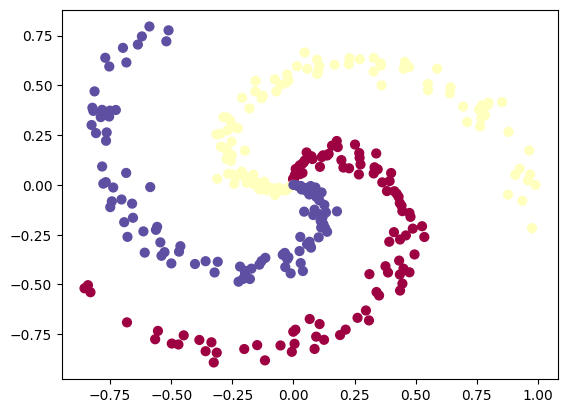

In [44]:
N = 100 # number of data points per class
D = 2 # data dimensionality
K = 3 # number of classes

X = np.zeros((N*K, D)) # data matrix
y = np.zeros(N*K, dtype='uint8') # class labels

for j in range(K):
  ix = range(N*j, N*(j+1))
  r = np.linspace(0.0, 1, N)
  t = np.linspace(j*4, (j+1) * 4, N) + np.random.randn(N) * 0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j

plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

## Training a Softmax Linear Classifier

In [45]:
def calc_scores(inputs):
  return np.dot(inputs, W) + b

def predict(inputs):
  return np.argmax(calc_scores(inputs), axis=1)

In [46]:
# initialize parameters randomly
W = 0.01 * np.random.randn(D,K)
b = np.zeros((1,K))

# some hyperparameters
step_size = 1e-0
reg = 1e-3 # regularization strength

num_examples = X.shape[0]


### Computing loss

In [47]:
def loss_and_probabilities():
  num_examples = X.shape[0]
  exp_scores = np.exp(scores)
  probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

  correct_logprobs = -np.log(probs[range(num_examples), y])
  data_loss = np.sum(correct_logprobs)/num_examples
  reg_loss = 0.5 * reg * np.sum(W*W) # we are doing this to avoid overfitting
  loss = data_loss + reg_loss
  
  return loss, probs

### Computing the analytic Gradient with Backpropagation

In [ ]:
def gradients(probs): # return dw & db
  d_scores = probs
  d_scores[range(num_examples), y] -= 1
  d_scores /= num_examples

  d_w = np.dot(X.T, d_scores)
  d_b = np.sum(d_scores, axis=0, keepdims=True)

  d_w += reg * W

  return d_w, d_b

### Running training loop

In [49]:
for i in range(200):
  scores = calc_scores(X)

  loss, probs = loss_and_probabilities()

  if i % 10 == 0:
    print(f"iteration {i}: loss {loss}")

  dW, db = gradients(probs)

  W += -step_size * dW
  b += -step_size * db

iteration 0: loss 1.1004366953404698
iteration 10: loss 0.9029495486075231
iteration 20: loss 0.8295776201160963
iteration 30: loss 0.79607556912963
iteration 40: loss 0.7784934940041516
iteration 50: loss 0.7683833405873648
iteration 60: loss 0.7621936357640867
iteration 70: loss 0.7582297707038241
iteration 80: loss 0.755604826128564
iteration 90: loss 0.7538212836366152
iteration 100: loss 0.7525847504134563
iteration 110: loss 0.7517135363141619
iteration 120: loss 0.7510916482094288
iteration 130: loss 0.7506429610453431
iteration 140: loss 0.7503163619034546
iteration 150: loss 0.7500768727758965
iteration 160: loss 0.7499001716916488
iteration 170: loss 0.7497691165067241
iteration 180: loss 0.7496714861977559
iteration 190: loss 0.7495984826526313


### Evaluate accuracy

In [50]:
predicted_class = np.argmax(scores, axis=1)
print(f'training accuracy: {np.mean(predicted_class == y):.2f}')


training accuracy: 0.51


### Plot the decision boundary

In [51]:
def plot_boundaries(X, y, predict):
  """Plot decision regions + data points.

  X       : (N, 2) data points to scatter
  y       : (N,)   true labels, used to color the dots
  predict : callable mapping (M, 2) grid points -> (M,) predicted class ids
  """
  h = 0.02   # grid resolution
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

  # classify every point on the grid (the classifier decides *how*)
  grid = np.c_[xx.ravel(), yy.ravel()]
  Z = predict(grid)                 # predicted class per grid point
  Z = Z.reshape(xx.shape)

  fig = plt.figure()
  plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)   # the colored regions
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral, edgecolors='k', linewidths=0.5)  # the data points
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.show()
  # plt.savefig('spiral_linear.png')   # to save it like the cs231n asset


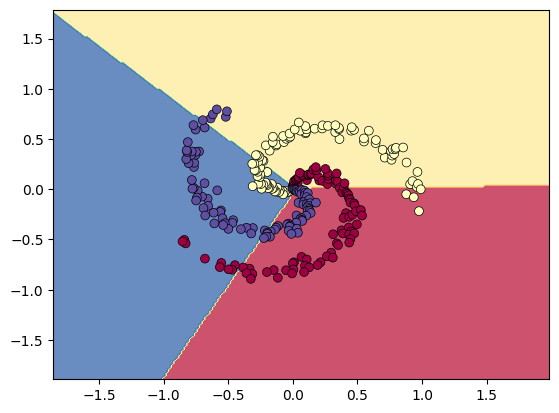

In [52]:
plot_boundaries(X, y, predict)

## Training a Neural Network with 2 layers

In [53]:
# initialize parameters randomly
h = 100
W = 0.01 * np.random.randn(D, h)
b = np.zeros((1, h))
W2 = 0.01 * np.random.randn(h, K)
b2 = np.zeros((1, K))

In [56]:
# some hyperparameters
step_size = 1e-0
reg = 1e-3 # regularization strength

num_examples = X.shape[0]

In [85]:
def calc_scores2(X):
  hidden_layer = np.maximum(0, np.dot(X, W) + b) # ReLU activation
  scores = np.dot(hidden_layer, W2) + b2

  return scores

def loss_probability_and_hidden_layer(X): # forward pass
  scores = calc_scores2(X)

  exp_scores = np.exp(scores)
  probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

  logprobs = -np.log(probs[range(num_examples), y])

  data_loss = np.sum(logprobs) / num_examples
  reg_loss = 0.5*reg*np.sum(W*W) + 0.5*reg*np.sum(W2*W2) # avoid overfitting
  loss = data_loss + reg_loss

  return loss, probs, hidden_layer


In [86]:
def gradients(probs, hidden_layer, X):
  d_scores = probs
  d_scores[range(num_examples), y] -= 1
  d_scores /= num_examples

  dW2 = np.dot(hidden_layer.T, d_scores)
  db2 = np.sum(d_scores, axis=0, keepdims=True)

  d_hidden = np.dot(d_scores, W2.T)

  d_hidden[hidden_layer <= 0] = 0

  dW = np.dot(X.T, d_hidden)
  db = np.sum(d_hidden, axis=0, keepdims=True)

  dW2 += reg * W2
  dW += reg * W

  return dW, db, dW2, db2

### Training loop for Neural network

In [87]:
for i in range(10000):
  loss, probs, hidden_layer = loss_probability_and_hidden_layer(X)
  
  if i % 1000 == 0:
    print(f"iteration {i}: loss {loss:.6f}")

  dW, db, dW2, db2 = gradients(probs, hidden_layer, X)

  W += -step_size * dW
  b += -step_size * db
  W2 += -step_size * dW2
  b2 += -step_size * db2

iteration 0: loss 0.252514
iteration 1000: loss 0.252531
iteration 2000: loss 0.254106
iteration 3000: loss 0.253224
iteration 4000: loss 0.255197
iteration 5000: loss 0.253686
iteration 6000: loss 0.253789
iteration 7000: loss 0.253949
iteration 8000: loss 0.253712
iteration 9000: loss 0.254231


### Training loop Accuracy

In [88]:
predicted_class = np.argmax(calc_scores(), axis=1)
accuracy = np.mean(predicted_class == y)
print(f"training accuracy: {accuracy:.2f}%")

training accuracy: 0.99%


### Plot decision boundaries

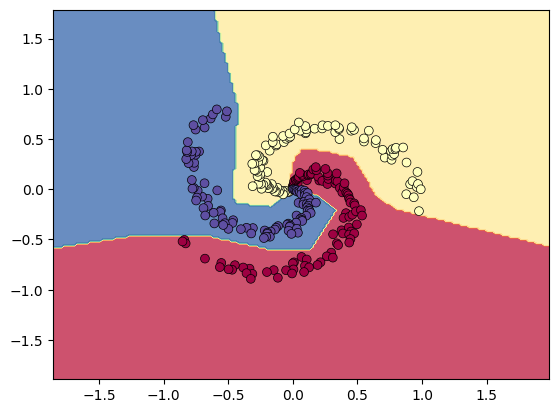

In [89]:
def predict_plot(inputs):
  return np.argmax(calc_scores2(inputs), axis=1)

plot_boundaries(X, y, predict_plot)